# Assignment 1 - Exploratory Data Analysis



## Abstract
Trong bài tập này, chúng ta sẽ cùng tìm hiểu cách phân tích dữ liệu và sử dụng model Decision Tree để đưa ra dự đoán cho bài toán classfication, cũng như quan sát kết quả của mô hình khi thay đổi siêu tham số của mô hình. Bộ dữ liệu huấn luyện được sử dụng là `penguins` - một bộ dữ liệu gồm các đặc điểm của một số loài chim cánh cụt. Từ những đặc điểm này, mục tiêu là huấn luyện một mô hình có thể phân loại được các loài chim cánh cụt có trong bộ dữ liệu.

## Import các thư viện cần thiết

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

## Quá trình xử lý tập dữ liệu `penguins`


**Lấy dữ liệu `penguins`**


In [72]:
df = sns.load_dataset("penguins")

In ra 5 giá trị đầu tiên của bộ dữ liệu để quan sát.

In [73]:
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


Hàm `info()` giúp ta biết được các đặc trưng của dữ liệu và loại của đặc trưng tương ứng.

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


**Kiểm tra xem dữ liệu có tồn tại cái dữ liệu trùng nhau không?**

In [75]:
print(f"Number of duplicates: {df.duplicated().sum()}")

Number of duplicates: 0


**Kiểm tra dữ liệu có các giá trị vô cực hay không?**

In [76]:
print(f"Number of inf data: {df.isin([np.inf, -np.inf]).sum().sum()}")

Number of inf data: 0


**Kiểm tra dữ liệu có các giá trị bị thiếu không?**

In [77]:
print(df[df.isnull().any(axis=1)])

    species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
3    Adelie  Torgersen             NaN            NaN                NaN   
8    Adelie  Torgersen            34.1           18.1              193.0   
9    Adelie  Torgersen            42.0           20.2              190.0   
10   Adelie  Torgersen            37.8           17.1              186.0   
11   Adelie  Torgersen            37.8           17.3              180.0   
47   Adelie      Dream            37.5           18.9              179.0   
246  Gentoo     Biscoe            44.5           14.3              216.0   
286  Gentoo     Biscoe            46.2           14.4              214.0   
324  Gentoo     Biscoe            47.3           13.8              216.0   
336  Gentoo     Biscoe            44.5           15.7              217.0   
339  Gentoo     Biscoe             NaN            NaN                NaN   

     body_mass_g  sex  
3            NaN  NaN  
8         3475.0  NaN  
9         4250.

Có rất nhiều phương pháp để xử lý các giá trị bị thiếu (missing data) như điền vào bằng giá trị trung bình, giá trị có tần xuất xuất hiện nhiều nhất, ... . Ở đây, vì số lượng missing data là không đáng kể nên ta có thể xóa (drop) các dữ liệu bị thiếu đó.

In [78]:
df = df.dropna()

Trong dữ liệu có các đặc trưng có loại dữ liệu là chữ, để thuận tiện trong việc train model, ta nên đưa các dữ liệu về số. Ở đây, ta sử dụng phương pháp `LabelEncoder()`.

In [79]:
from sklearn.preprocessing import LabelEncoder

df = df.apply(LabelEncoder().fit_transform)
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,0,2,41,56,5,30,1
1,0,2,44,43,10,32,0
2,0,2,50,49,19,11,0
4,0,2,21,62,17,18,0
5,0,2,43,73,14,26,1
...,...,...,...,...,...,...,...
338,2,0,107,6,37,68,0
340,2,0,104,12,38,65,0
341,2,0,135,26,45,86,1
342,2,0,88,17,35,75,0


Hàm `decrise()` giúp chúng ta hiểu hơn về phân bố của các đặc trưng trong bộ dữ liệu.

In [80]:
df.describe()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
count,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000
mean,0.918919,0.651652,80.432432,40.525526,24.576577,43.048048,0.504505
std,0.889718,0.714715,43.902951,19.461503,13.429568,24.691789,0.500732
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,44.000000,25.000000,14.000000,22.000000,0.000000
50%,1.000000,1.000000,84.000000,42.000000,21.000000,40.000000,1.000000
75%,2.000000,1.000000,118.000000,56.000000,36.000000,63.000000,1.000000
max,2.000000,2.000000,162.000000,78.000000,53.000000,92.000000,1.000000


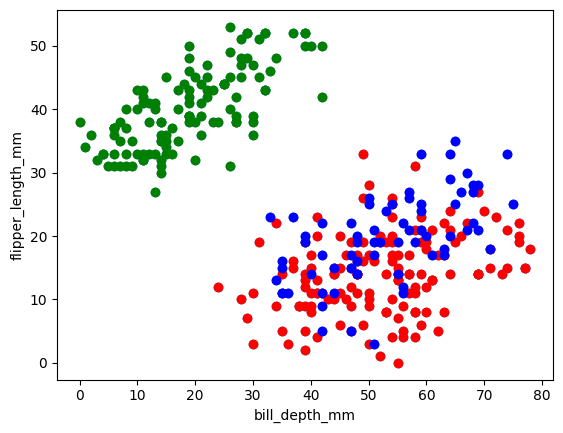

In [100]:
plt.scatter(df['bill_depth_mm'], df['flipper_length_mm'])
plt.xlabel('bill_depth_mm')
plt.ylabel('flipper_length_mm')
colors = ['red', 'blue', 'green']
for i in range(3):
  plt.scatter(df[df['species'] == i]['bill_depth_mm'], df[df['species'] == i]['flipper_length_mm'], color=colors[i])

Biểu đồ trên thể hiện sự phân hóa các loài dựa vào `bill_depth_mm` và `flipper_length_mm`.

Dễ thấy, với `flipper_length_mm' lớn hơn 26 và `bill_depth_mm` nhỏ hơn 45, ta có thể tạm khẳng định nó thuộc loài Gentoo.

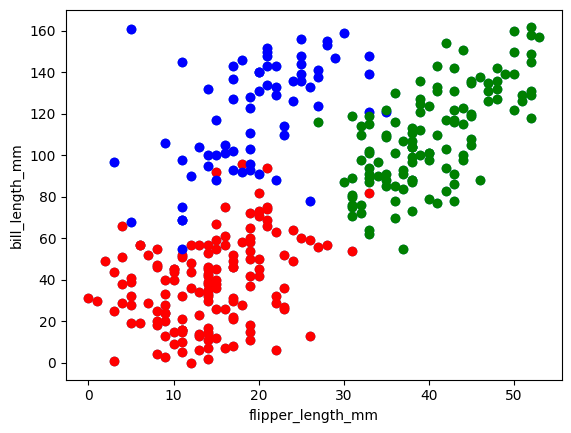

In [103]:
plt.scatter(df['flipper_length_mm'], df['bill_length_mm'])
plt.xlabel('flipper_length_mm')
plt.ylabel('bill_length_mm')
colors = ['red', 'blue', 'green']
for i in range(3):
  plt.scatter(df[df['species'] == i]['flipper_length_mm'], df[df['species'] == i]['bill_length_mm'], color=colors[i])

Biểu đồ trên thể hiện sự phân hóa các loài dựa vào `flipper_length_mm` và `bill_length_mm`.

Dễ thấy:
+ Hầu hết các loài Gentoo có giá trị `flipper_length_mm` lớn hơn 26.
+ Ngoài ra, với loài Chinstrap có giá trị `flipper_length_mm` nhỏ hơn 32, và giá trị `bill_length_mm` thường lớn hơn 60.
+ Cuối cùng, loài Adelie có giá trị `flipper_length_mm` bé hơn 30 và `bill_length_mm` thường bé hơn 90.

**Ta cần tách tập đặc trưng (features) và tập kết quả (target) từ tập dữ liệu ban đầu**

In [82]:
# Split the data into features and target
X = df.drop(columns=['species'])
y = df['species']

In [83]:
X, y

(     island  bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g  \
 0         2              41             56                  5           30   
 1         2              44             43                 10           32   
 2         2              50             49                 19           11   
 4         2              21             62                 17           18   
 5         2              43             73                 14           26   
 ..      ...             ...            ...                ...          ...   
 338       0             107              6                 37           68   
 340       0             104             12                 38           65   
 341       0             135             26                 45           86   
 342       0              88             17                 35           75   
 343       0             130             30                 36           79   
 
      sex  
 0      1  
 1      0  
 2      0  
 4

**Sử dụng hàm `train_test_split` để tách tập thành tập train để huấn luyện mô hình và tập test để đánh giá mô hình**

Ở đây với `test_size = 0.2` tức có 80% là bộ train, và 20% là bộ test.

In [84]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=24521901)

## Huấn luyện mô hình

**Để sử dụng mô hình ta gọi `DecisionTreeClassifier` trong thư viện scikit-learn. Dùng hàm `fix(X, y)` để model tự học với bộ dữ liệu huấn luyện**
Ở đây ta sẽ lấy giới hạn độ sâu của cây `max_depth` là 3.

In [85]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(max_depth=3, random_state=24521901)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=24521901)

Sau khi cho mô hình học dữ liệu từ tập huấn luyện, ta có trực quan hóa Decision Tree bằng cách sử dụng thư viện `graphviz`

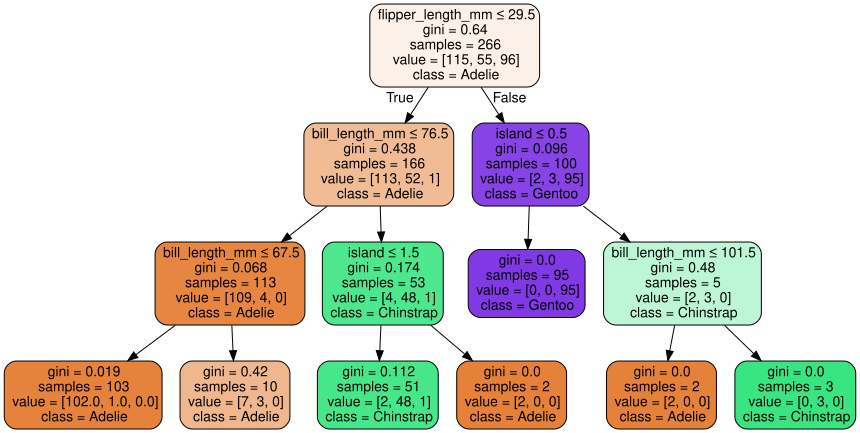

In [86]:
from graphviz import Source
from sklearn.tree import export_graphviz

# plot tree
dot_data = export_graphviz(model, out_file=None, feature_names=X.columns, class_names=['Adelie', 'Chinstrap', 'Gentoo'], filled=True, rounded=True, special_characters=True)
graph = Source(dot_data)
graph.render("decision_tree")
graph

## Đánh giá mô hình


Để đánh giá mô hình, ta sử dụng `confusion_matrix` trong thư viện metrics của scikit-learn.


In [87]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

def cm_plot(y_test, y_pred):
  confuse_matrix = confusion_matrix(y_test, y_pred)
  display = ConfusionMatrixDisplay(confusion_matrix=confuse_matrix)
  display.plot()

**y_pred** là kết quả dự đoán của mô hình khi chạy tập dữ liệu test.

**y_test** là kết quả đúng của tập dữ liệu test.



              precision    recall  f1-score   support

           0       1.00      1.00      1.00        31
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        23

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



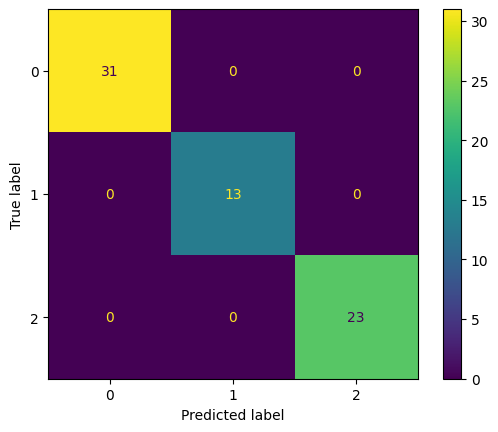

In [98]:
y_pred = model.predict(X_test)

print(classification_report(y_test,y_pred, target_names=['Adelie', 'Chinstrap', 'Gentoo']))

cm_plot(y_test, y_pred)

## Đánh giá kết quả mô hình khi thay đổi hyperparameter `max_depth` của mô hình

Ở phần này, ta sẽ phân tích kết quả đánh giá khi thay đổi tham số `max_depth` của mô hình.


With max_depth = 2, the accuracy of model is 0.9850746268656716
With max_depth = 3, the accuracy of model is 0.9850746268656716
With max_depth = 4, the accuracy of model is 0.9850746268656716
With max_depth = 5, the accuracy of model is 1.0
With max_depth = 6, the accuracy of model is 1.0
With max_depth = 7, the accuracy of model is 1.0
With max_depth = 8, the accuracy of model is 1.0
With max_depth = 9, the accuracy of model is 1.0


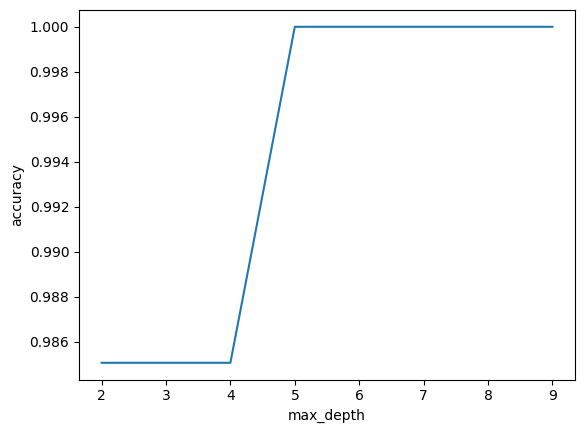

In [91]:
from sklearn.metrics import accuracy_score

accuracy_list = []

for max_depth in range(2, 10):
  model = DecisionTreeClassifier(max_depth=max_depth, random_state=24521901)
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  accuracy = accuracy_score(y_test, y_pred)
  accuracy_list.append(accuracy)
  print(f"With max_depth = {max_depth}, the accuracy of model is {accuracy}")

# plot the accuracy_list and max_depth
plt.plot(range(2, 10), accuracy_list)
plt.xlabel('max_depth')
plt.ylabel('accuracy')
plt.show()


$⇒$ Từ kết quả trên, ta kết luận, mô hình đã overfit kể từ max_depth = 5 trở đi.

## Kết luận

Như vậy, với mô hình Decision Tree, ta đạt độ chính xác (accuracy) lên tới $98,5\%$. Siêu tham số `max_depth` nên đặt vào khoảng $3, 4$ nếu đặt quá lớn sẽ dẫn đến tình trạng overfitting.